In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving used_car_regression_lab_dataset.xlsx to used_car_regression_lab_dataset.xlsx


In [ ]:
df = pd.read_excel("used_car_regression_lab_dataset.xlsx")

df.head()

,Brand,Model,Year,Fuel_Type,Transmission,Engine_Size_L,Mileage_km,Owner_Count,Condition,Price
0,Hyundai,i20,2022.0,Diesel,Manual,1.80,100863.0,1.0,Fair,847998.0
1,Toyota,Corolla,2023.0,Petrol,Manual,1.83,20495.0,1.0,Fair,1060540.0
2,Ford,EcoSport,2022.0,Petrol,Manual,1.83,39910.0,3.0,Good,981050.0
3,Toyota,Yaris,2019.0,Diesel,Manual,1.15,154737.0,2.0,Good,577527.0
4,Toyota,Yaris,2011.0,NaN,Manual,1.80,208745.0,3.0,Good,357711.0


In [ ]:
df.head()

,Brand,Model,Year,Fuel_Type,Transmission,Engine_Size_L,Mileage_km,Owner_Count,Condition,Price
0,Hyundai,i20,2022.0,Diesel,Manual,1.80,100863.0,1.0,Fair,847998.0
1,Toyota,Corolla,2023.0,Petrol,Manual,1.83,20495.0,1.0,Fair,1060540.0
2,Ford,EcoSport,2022.0,Petrol,Manual,1.83,39910.0,3.0,Good,981050.0
3,Toyota,Yaris,2019.0,Diesel,Manual,1.15,154737.0,2.0,Good,577527.0
4,Toyota,Yaris,2011.0,NaN,Manual,1.80,208745.0,3.0,Good,357711.0


In [ ]:
df.tail()

,Brand,Model,Year,Fuel_Type,Transmission,Engine_Size_L,Mileage_km,Owner_Count,Condition,Price
1001,Ford,Aspire,2011.0,Petrol,Automatic,2.43,183408.0,4.0,Good,518049.0
1002,Maruti,Baleno,2019.0,Petrol,Manual,1.18,148937.0,2.0,Excellent,576577.0
1003,Toyota,Yaris,2021.0,CNG,Manual,1.78,185546.0,1.0,Excellent,680196.0
1004,Ford,Aspire,2013.0,Petrol,Automatic,1.95,16092.0,4.0,Excellent,896561.0
1005,Toyota,Corolla,2014.0,Petrol,Manual,1.52,81485.0,4.0,Good,605978.0


In [ ]:
df.shape

(1006, 10)

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Brand          1005 non-null   object 
 1   Model          1005 non-null   object 
 2   Year           1005 non-null   float64
 3   Fuel_Type      985 non-null    object 
 4   Transmission   1005 non-null   object 
 5   Engine_Size_L  985 non-null    float64
 6   Mileage_km     1005 non-null   float64
 7   Owner_Count    1005 non-null   float64
 8   Condition      1005 non-null   object 
 9   Price          1005 non-null   float64
dtypes: float64(5), object(5)
memory usage: 78.7+ KB


In [ ]:
df.describe()

,Year,Engine_Size_L,Mileage_km,Owner_Count,Price
count,1005.000000,985.000000,1005.000000,1005.000000,1.005000e+03
mean,2017.485572,1.728142,108115.964179,2.486567,7.371167e+05
std,4.647863,0.453813,65012.795499,1.109120,2.197548e+05
min,1992.000000,1.000000,5247.000000,1.000000,1.916870e+05
25%,2014.000000,1.350000,53382.000000,1.000000,5.935930e+05
50%,2017.000000,1.730000,105622.000000,3.000000,7.419240e+05
75%,2021.000000,2.100000,159650.000000,3.000000,8.726550e+05
max,2025.000000,5.800000,700000.000000,4.000000,2.800000e+06


In [ ]:
df.isnull().sum()

,0
Brand,1
Model,1
Year,1
Fuel_Type,21
Transmission,1
Engine_Size_L,21
Mileage_km,1
Owner_Count,1
Condition,1
Price,1


In [ ]:
numerical_cols = ["Year", "Engine_Size_L", "Mileage_km", "Owner_Count", "Price"]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
categorical_cols = ["Brand", "Model", "Fuel_Type", "Transmission", "Condition"]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
Brand,0
Model,0
Year,0
Fuel_Type,0
Transmission,0
Engine_Size_L,0
Mileage_km,0
Owner_Count,0
Condition,0
Price,0


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5


In [ ]:
df[df.duplicated()]

,Brand,Model,Year,Fuel_Type,Transmission,Engine_Size_L,Mileage_km,Owner_Count,Condition,Price
1001,Ford,Aspire,2011.0,Petrol,Automatic,2.43,183408.0,4.0,Good,518049.0
1002,Maruti,Baleno,2019.0,Petrol,Manual,1.18,148937.0,2.0,Excellent,576577.0
1003,Toyota,Yaris,2021.0,CNG,Manual,1.78,185546.0,1.0,Excellent,680196.0
1004,Ford,Aspire,2013.0,Petrol,Automatic,1.95,16092.0,4.0,Excellent,896561.0
1005,Toyota,Corolla,2014.0,Petrol,Manual,1.52,81485.0,4.0,Good,605978.0


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(1001, 10)

In [ ]:
numerical_cols = ["Year", "Engine_Size_L", "Mileage_km", "Owner_Count", "Price"]

numerical_cols

['Year', 'Engine_Size_L', 'Mileage_km', 'Owner_Count', 'Price']

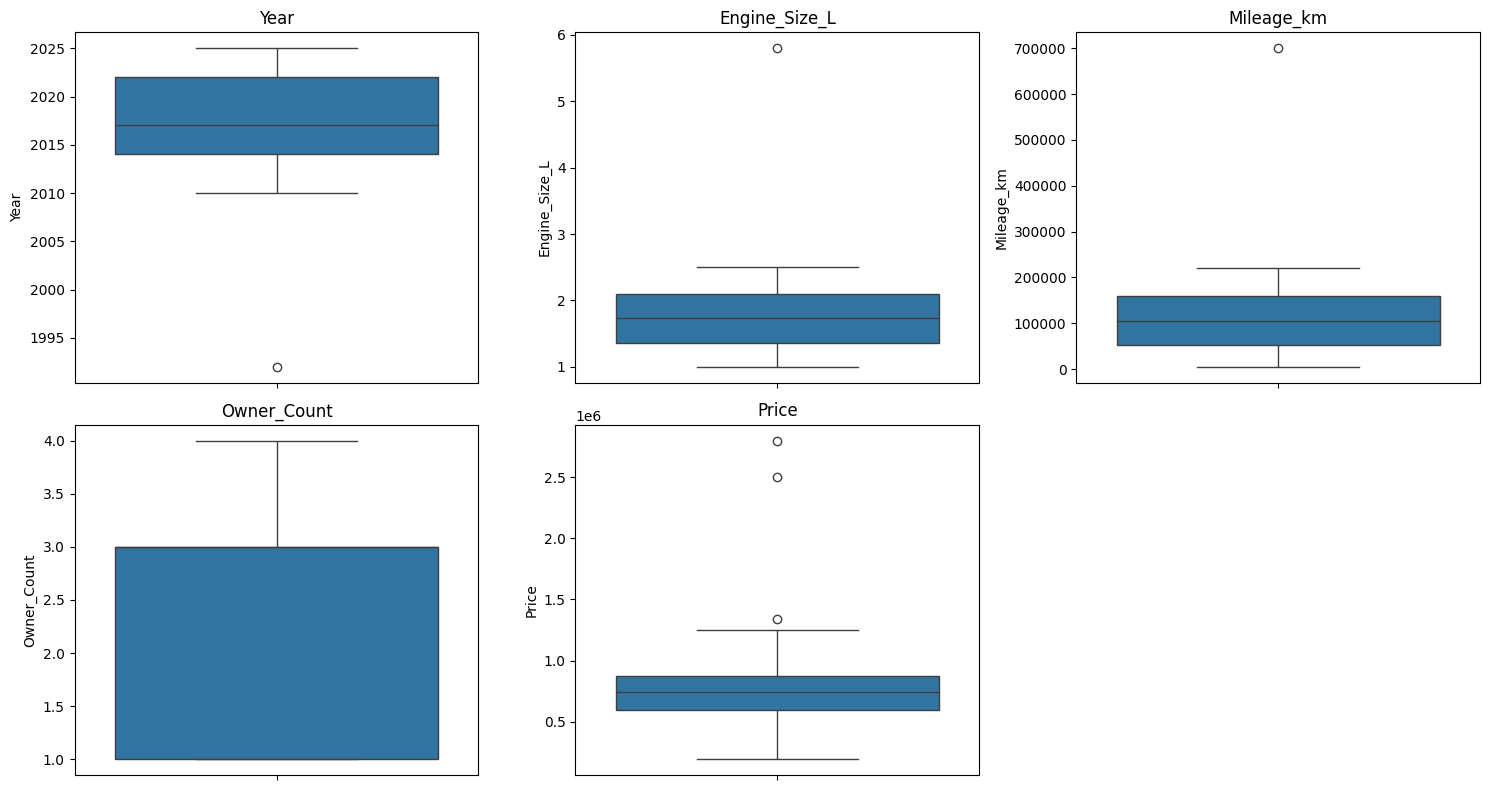

In [ ]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Year: 1 outliers
Engine_Size_L: 1 outliers
Mileage_km: 1 outliers
Owner_Count: 0 outliers
Price: 3 outliers


In [ ]:
df_clean = df.copy()

for col in numerical_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

print("Original Shape :", df.shape)
print("Shape after removing outliers :", df_clean.shape)

Original Shape : (1001, 10)
Shape after removing outliers : (995, 10)


In [ ]:
for col in numerical_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower) |
        (df_clean[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

Year: 0 outliers
Engine_Size_L: 0 outliers
Mileage_km: 0 outliers
Owner_Count: 0 outliers
Price: 0 outliers


In [ ]:
df.select_dtypes(include="object").columns

Index(['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Condition'], dtype='object')

In [ ]:
df = pd.get_dummies(
    df,
    columns=["Brand", "Model", "Fuel_Type", "Transmission", "Condition"],
    drop_first=True
)

In [ ]:
df.head()

,Year,Engine_Size_L,Mileage_km,Owner_Count,Price,Brand_Honda,Brand_Hyundai,Brand_Maruti,Brand_Toyota,Model_Aspire,...,Model_Figo,Model_Swift,Model_Verna,Model_Yaris,Model_i20,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Manual,Condition_Fair,Condition_Good
0,2022.0,1.80,100863.0,1.0,847998.0,False,True,False,False,False,...,False,False,False,False,True,True,False,True,True,False
1,2023.0,1.83,20495.0,1.0,1060540.0,False,False,False,True,False,...,False,False,False,False,False,False,True,True,True,False
2,2022.0,1.83,39910.0,3.0,981050.0,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
3,2019.0,1.15,154737.0,2.0,577527.0,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,True
4,2011.0,1.80,208745.0,3.0,357711.0,False,False,False,True,False,...,False,False,False,True,False,False,True,True,False,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001 entries, 0 to 1000
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 1001 non-null   float64
 1   Engine_Size_L        1001 non-null   float64
 2   Mileage_km           1001 non-null   float64
 3   Owner_Count          1001 non-null   float64
 4   Price                1001 non-null   float64
 5   Brand_Honda          1001 non-null   bool   
 6   Brand_Hyundai        1001 non-null   bool   
 7   Brand_Maruti         1001 non-null   bool   
 8   Brand_Toyota         1001 non-null   bool   
 9   Model_Aspire         1001 non-null   bool   
 10  Model_Baleno         1001 non-null   bool   
 11  Model_Camry          1001 non-null   bool   
 12  Model_City           1001 non-null   bool   
 13  Model_Civic          1001 non-null   bool   
 14  Model_Corolla        1001 non-null   bool   
 15  Model_Creta          1001 non-null   bool  

In [ ]:
numerical_features = ["Year", "Engine_Size_L", "Mileage_km", "Owner_Count"]

In [ ]:
scaler = StandardScaler()

df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [ ]:
df.head()

,Year,Engine_Size_L,Mileage_km,Owner_Count,Price,Brand_Honda,Brand_Hyundai,Brand_Maruti,Brand_Toyota,Model_Aspire,...,Model_Figo,Model_Swift,Model_Verna,Model_Yaris,Model_i20,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Manual,Condition_Fair,Condition_Good
0,0.969908,0.160457,-0.110501,-1.341389,847998.0,False,True,False,False,False,...,False,False,False,False,True,True,False,True,True,False
1,1.185180,0.227278,-1.348127,-1.341389,1060540.0,False,False,False,True,False,...,False,False,False,False,False,False,True,True,True,False
2,0.969908,0.227278,-1.049146,0.465785,981050.0,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
3,0.324091,-1.287347,0.719130,-0.437802,577527.0,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,True
4,-1.398087,0.160457,1.550826,0.465785,357711.0,False,False,False,True,False,...,False,False,False,True,False,False,True,True,False,True


In [ ]:
df[numerical_features].describe()

,Year,Engine_Size_L,Mileage_km,Owner_Count
count,1.001000e+03,1.001000e+03,1.001000e+03,1.001000e+03
mean,-1.720901e-14,7.098329e-18,-6.388496e-17,-1.135733e-16
std,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,-5.488258e+00,-1.621455e+00,-1.582938e+00,-1.341389e+00
25%,-7.522699e-01,-8.195949e-01,-8.416843e-01,-1.341389e+00
50%,-1.064533e-01,4.539336e-03,-3.721531e-02,4.657852e-01
75%,9.699077e-01,8.063997e-01,7.901836e-01,4.657852e-01
max,1.615724e+00,9.070016e+00,9.115899e+00,1.369372e+00


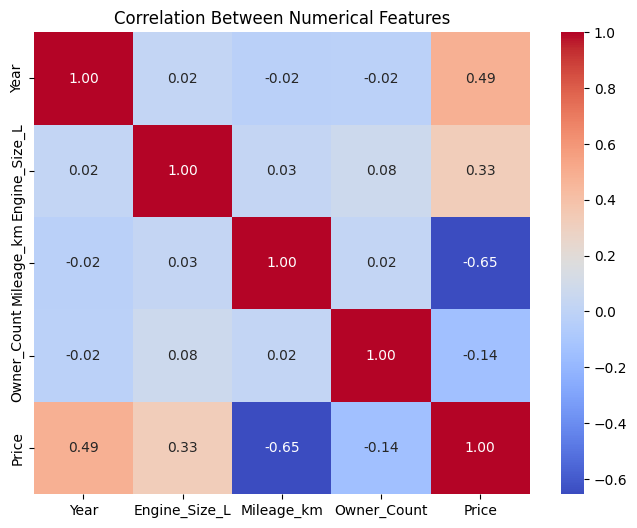

In [ ]:
important_cols = [
    "Year",
    "Engine_Size_L",
    "Mileage_km",
    "Owner_Count",
    "Price"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[important_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()

In [ ]:
X = df[["Mileage_km"]]
y = df["Price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Intercept:", model.intercept_)

print("Coefficient:", model.coef_[0])

Intercept: 739165.0045828838
Coefficient: -139915.65565359948


In [ ]:
print("MAE :", mean_absolute_error(y_test, y_pred))

print("MSE :", mean_squared_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R² Score :", r2_score(y_test, y_pred))

MAE : 114151.4695260788
MSE : 19248043377.956894
RMSE : 138737.31789953593
R² Score : 0.540436015777107


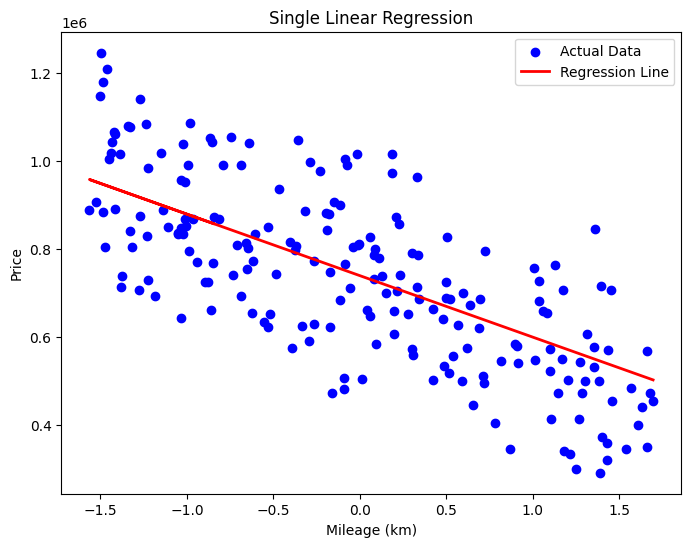

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_test,
    y_test,
    color="blue",
    label="Actual Data"
)

plt.plot(
    X_test,
    y_pred,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Mileage (km)")
plt.ylabel("Price")
plt.title("Single Linear Regression")

plt.legend()

plt.show()

In [ ]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
multiple_model = LinearRegression()

In [ ]:
multiple_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_multi = multiple_model.predict(X_test)

In [ ]:
print("Intercept:")
print(multiple_model.intercept_)

print("\nCoefficients:")

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": multiple_model.coef_
})

coefficients

Intercept:
827263.1222881761

Coefficients:


,Feature,Coefficient
0,Year,104755.575774
1,Engine_Size_L,80737.947816
2,Mileage_km,-144279.775954
3,Owner_Count,-31513.364129
4,Brand_Honda,-12014.422123
5,Brand_Hyundai,379.569188
6,Brand_Maruti,-8203.966277
7,Brand_Toyota,-6551.226018
8,Model_Aspire,-6772.374931
9,Model_Baleno,-3316.779481


In [ ]:
print("MAE :", mean_absolute_error(y_test, y_pred_multi))
print("MSE :", mean_squared_error(y_test, y_pred_multi))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_multi)))
print("R² Score :", r2_score(y_test, y_pred_multi))

MAE : 28213.353922516224
MSE : 4781048354.382492
RMSE : 69145.1253117853
R² Score : 0.8858482606591285


In [ ]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred_multi
})

comparison["Predicted Price"] = comparison["Predicted Price"].round(0).astype(int)

comparison.head(10)

,Actual Price,Predicted Price
521,452884.0,481818
941,1086113.0,1061034
741,545365.0,566797
980,1141821.0,1127994
411,1017531.0,1038288
679,1042537.0,990313
673,851471.0,834018
513,772926.0,766704
773,951410.0,964600
136,804421.0,820105


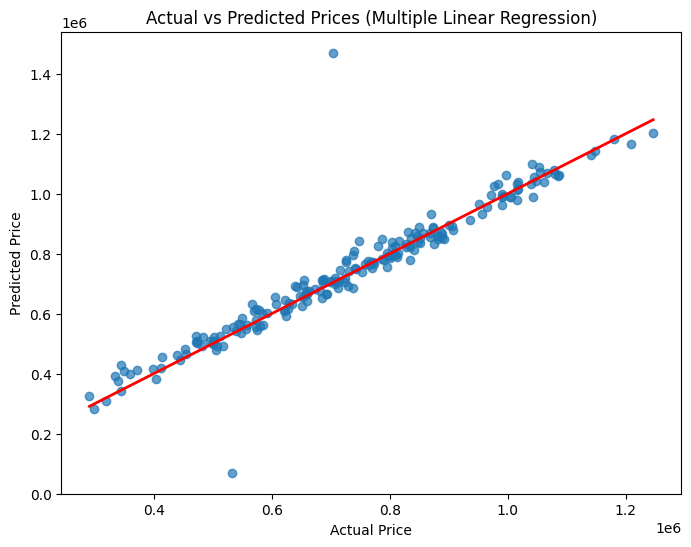

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_multi, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Multiple Linear Regression)")

plt.show()